# <font color='#1083D6'>Business Insights and Customer Segment Interpretation</font>

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

path_cluster = "../data_clean/rfm_cluster.csv"
path_rfm_original = "../data_raw/raw_rfm_metrics.csv"
path_original = "../data_clean/clean_online_retail.csv"


df_cluster = pd.read_csv(path_cluster)
df_rfm = pd.read_csv(path_rfm_original)
df_original = pd.read_csv(path_original)

df_rfm['Cluster'] = df_cluster['Cluster']

## <font color='#1083D6'>Visualizations of Customer Segments Features</font> 

The following graphs were built for the customer segment analysis and further interpretations.

### Customer Segment Overview

The following table summarizes the main RFM metrics and customer distribution for each cluster. These aggregated statistics provide an initial overview of customer purchasing behavior and reveal significant differences in recency, purchase frequency, and monetary contribution across customer segments. Additionally, a bar graph plot is included to visually understand the difference in customer distribution between clusters.

In [13]:
cluster_summary = df_rfm.groupby('Cluster').agg({
    'Recency': ['mean', 'median'],
    'Frequency': ['mean', 'median'],
    'Monetary': ['mean', 'median'],
    'Cluster': 'count'
})

cluster_summary.rename(columns={'count': 'Customers'}, level=1, inplace=True)

cluster_summary

Recency          Frequency             Monetary            \
               mean median        mean median          mean    median   
Cluster                                                                 
0         44.687601   22.0  432.305153  293.5  10665.494854  4967.170   
1        118.081147   65.0   88.859572   76.0   1461.299688  1203.875   
2        503.278808  477.0   27.164238   21.0    494.304432   320.125   
3        117.008427   79.0   17.424157   16.0    350.143596   301.060   

          Cluster  
        Customers  
Cluster            
0            1242  
1            2058  
2            1510  
3            1068

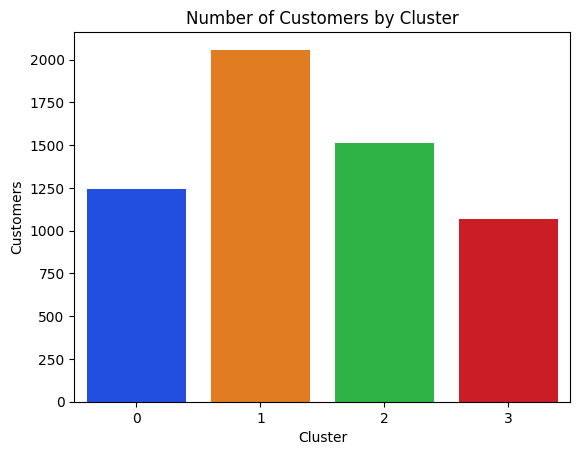

In [14]:
qual_palette = sns.color_palette("bright", 4)

cluster_sizes = df_rfm['Cluster'].value_counts().sort_index()

sns.barplot(
    x=cluster_sizes.index,
    y=cluster_sizes.values,
    palette=qual_palette, 
    hue=cluster_sizes.index, 
    legend=False,
)

plt.title("Number of Customers by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Customers")

plt.show()

### Average RFM Behavior by Cluster

The following visualizations compare the average Recency, Frequency, and Monetary values across clusters. These metrics help identify behavioral differences between customer groups and provide insight into customer engagement, purchasing activity, and revenue contribution.

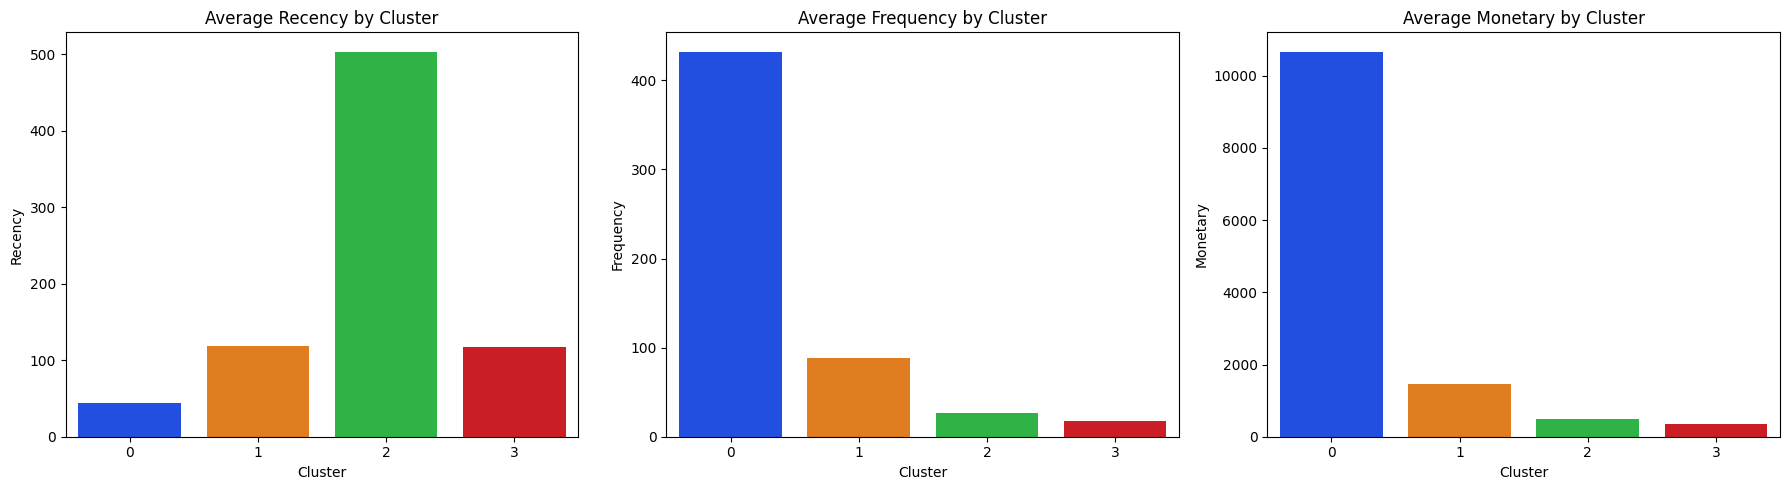

In [15]:
qual_palette = sns.color_palette("bright", 4)

cluster_means = df_rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.barplot(
    x=cluster_means.index,
    y=cluster_means['Recency'],
    palette=qual_palette, 
    hue=cluster_means.index, 
    legend=False,
    ax=axes[0]
)

axes[0].set_title('Average Recency by Cluster')

sns.barplot(
    x=cluster_means.index,
    y=cluster_means['Frequency'],
    palette=qual_palette, 
    hue=cluster_means.index, 
    legend=False,
    ax=axes[1]
)

axes[1].set_title('Average Frequency by Cluster')

sns.barplot(
    x=cluster_means.index,
    y=cluster_means['Monetary'],
    palette=qual_palette, 
    hue=cluster_means.index, 
    legend=False,
    ax=axes[2]
)

axes[2].set_title('Average Monetary by Cluster')

plt.tight_layout()
plt.show()

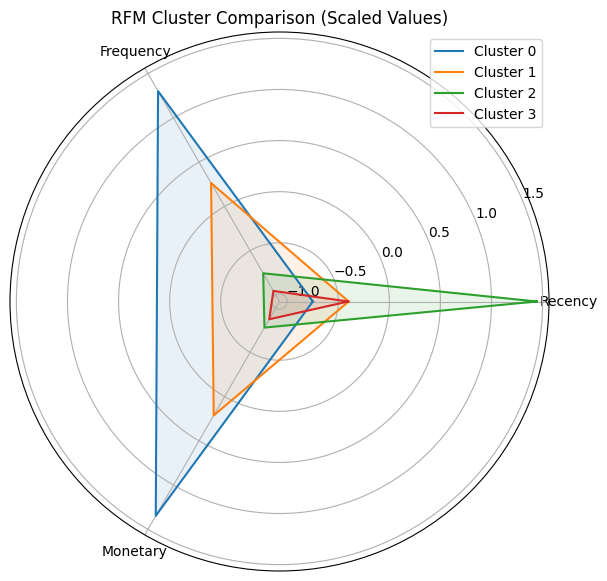

In [16]:
# Mean scaled values by cluster
radar_data = df_cluster.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

# Categories
categories = ['Recency', 'Frequency', 'Monetary']
N = len(categories)

# Angle setup
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

# Create figure
fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))

# Plot each cluster
for cluster in radar_data.index:
    
    values = radar_data.loc[cluster].tolist()
    values += values[:1]

    ax.plot(angles, values, label=f'Cluster {cluster}')
    ax.fill(angles, values, alpha=0.1)

# Labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)

plt.title("RFM Cluster Comparison (Scaled Values)")
plt.legend(loc='upper right')

plt.show()

### RFM Distribution and Behavioral Variability

The following boxplots illustrate the distribution and variability of RFM metrics within each cluster. These visualizations help identify the presence of outliers, customer heterogeneity, and differences between average behavior and the typical customer within each segment.

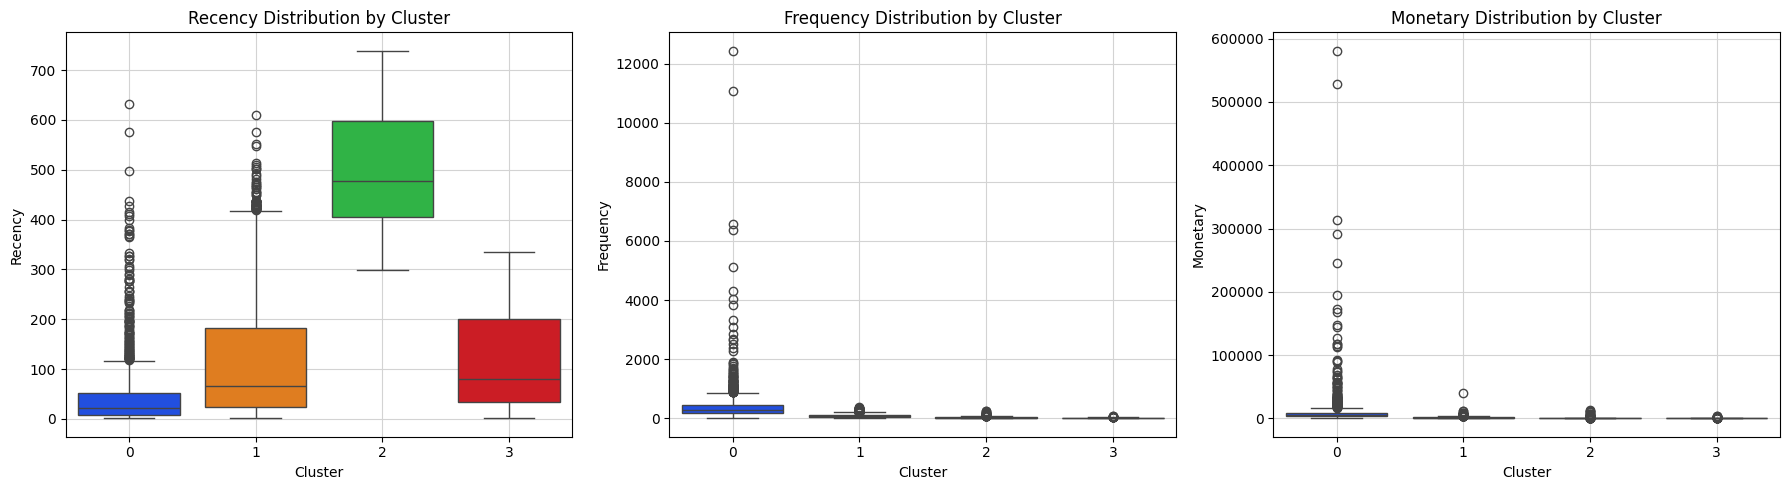

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.boxplot(
    data=df_rfm,
    x='Cluster',
    y='Recency',
    palette=qual_palette, 
    hue='Cluster', 
    legend=False,
    ax=axes[0]
)

axes[0].set_title('Recency Distribution by Cluster')
axes[0].grid(color="lightgray")

sns.boxplot(
    data=df_rfm,
    x='Cluster',
    y='Frequency',
    palette=qual_palette, 
    hue='Cluster', 
    legend=False,
    ax=axes[1]
)

axes[1].set_title('Frequency Distribution by Cluster')
axes[1].grid(color="lightgray")

sns.boxplot(
    data=df_rfm,
    x='Cluster',
    y='Monetary',
    palette=qual_palette, 
    hue='Cluster', 
    legend=False,
    ax=axes[2]
)

axes[2].set_title('Monetary Distribution by Cluster')
axes[2].grid(color="lightgray")

plt.tight_layout()
plt.show()

### Revenue contribution by cluster

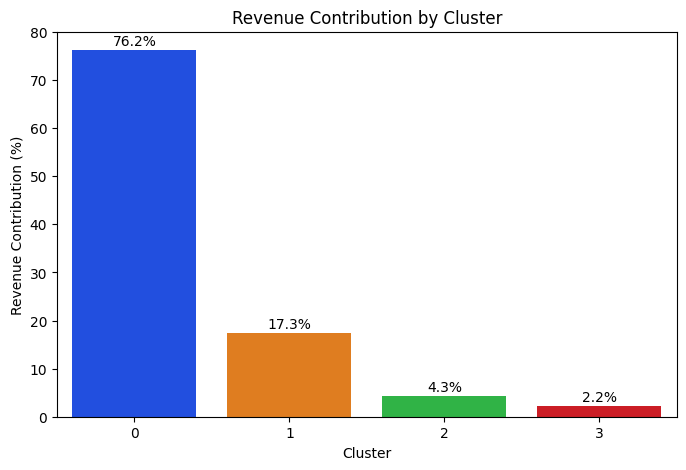

In [18]:
# Revenue by cluster
revenue_cluster = df_rfm.groupby('Cluster')['Monetary'].sum().sort_values(ascending=False)

# Revenue percentage
revenue_percentage = (revenue_cluster / revenue_cluster.sum()) * 100

cluster_order = revenue_percentage.index

plt.figure(figsize=(8,5))

sns.barplot(
    x=revenue_percentage.index,
    y=revenue_percentage.values,
    order=cluster_order,
    palette=qual_palette,
    hue=revenue_percentage.index,
    legend=False
)

plt.title("Revenue Contribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Revenue Contribution (%)")

# Labels
for i, value in enumerate(revenue_percentage.values):
    plt.text(i, value + 1, f"{value:.1f}%", ha='center')

plt.show()

## <font color='#1083D6'>Customer Distribution Across Clusters</font> 

### Customer Distribution and Revenue Contribution

The following comparison illustrates the relationship between customer population size and revenue contribution for each cluster. This analysis helps identify which customer groups generate the highest business value relative to their size and highlights potential priorities for customer retention and marketing strategies.

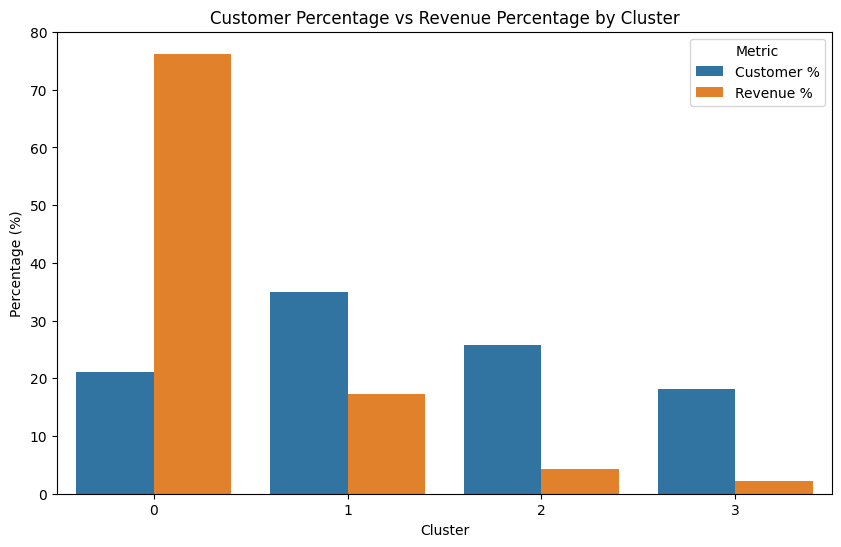

In [19]:
# Customer percentage
customer_percentage = (
    df_rfm['Cluster']
    .value_counts(normalize=True)
    .sort_index() * 100
)

# Revenue percentage
revenue_percentage = (
    df_rfm.groupby('Cluster')['Monetary']
    .sum()
    .sort_index()
)

revenue_percentage = (
    revenue_percentage / revenue_percentage.sum()
) * 100

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Customer %': customer_percentage,
    'Revenue %': revenue_percentage
})

# Reshape for seaborn
comparison_melted = comparison_df.reset_index().melt(
    id_vars='Cluster',
    var_name='Metric',
    value_name='Percentage'
)

# Plot
plt.figure(figsize=(10,6))

sns.barplot(
    data=comparison_melted,
    x='Cluster',
    y='Percentage',
    hue='Metric'
)

plt.title("Customer Percentage vs Revenue Percentage by Cluster")
plt.ylabel("Percentage (%)")

plt.show()

### <font color='#DD2D4A'>Key Findings</font>

The clustering process produced <font color='#F26A8D'>four customer groups</font> with relatively balanced sizes, indicating that the segmentation model was able to distribute customers into differentiated behavioral groups rather than concentrating them into a single dominant segment.

<font color='#F26A8D'>Cluster 1 contains the largest number of customers with 2,058 customers</font>, while <font color='#F26A8D'>Cluster 3 is the smallest group with 1,068 customers</font>. The difference between both groups is approximately 92%, showing that the customer base is not evenly distributed across purchasing behaviors.

Additionally, despite <font color='#F26A8D'>Cluster 0</font> representing only around <font color='#F26A8D'>21% of customers</font>, it <font color='#F26A8D'>contributes approximately 76% of the company’s total revenue</font>. This result strongly suggests the <font color='#F26A8D'>presence of a high-value customer segment </font>responsible for a disproportionately large share of sales revenue.

### <font color='#DD2D4A'>Business Interpretation</font>

The customer base follows a highly <font color='#F26A8D'>unequal revenue distribution pattern</font>, similar to the Pareto Principle (80/20 rule), where a relatively <font color='#F26A8D'>small proportion of customers generates most of the revenue</font>.

For the CRM and marketing teams implies that:
- <font color='#F26A8D'>customer retention efforts should not be applied uniformly</font>,
- <font color='#F26A8D'>high-value customers require priority retention strategies</font>,
- <font color='#F26A8D'>low-value or inactive customers may require reactivation campaigns or cost-efficient engagement strategies</font>.

The results also indicate that the business depends heavily on Cluster 0 customers, which may represent wholesalers or highly engaged buyers.

### <font color='##20BF55'>Recommended Business Actions</font>
- Develop differentiated CRM strategies for each cluster instead of applying the same marketing strategy to all customers.
- Prioritize retention efforts for high-value customers.
- Implement reactivation campaigns for inactive segments.
- Optimize marketing spending by targeting customers according to their behavioral value.

## <font color='#1083D6'>Cluster 0 — High-Value Customers</font> 

### <font color='#DD2D4A'>Key Findings</font>

Cluster 0 represents the <font color='#F26A8D'>most valuable customer segment in the dataset</font>.

This group shows:
<font color='#F26A8D'>
- the lowest average recency,
- the highest purchase frequency,
- the highest monetary contribution.

</font>

<font color='#F26A8D'>Customers in this segment generate approximately 76% of the company’s total revenue despite representing only around 21% of all customers</font>.

The boxplots also reveal the presence of extremely high-value outliers within this segment, suggesting that some customers behave similarly to wholesalers or bulk buyers.

Although the average recency is very low, the boxplots show moderate variability, meaning that <font color='#F26A8D'>not all customers purchase at the same frequency or recency level</font>.

### <font color='#DD2D4A'>Business Interpretation</font>

Cluster 0 can be interpreted as the <font color='#F26A8D'>company’s core segment for revenue</font>.

These customers:
- purchase frequently,
- spend significantly more than other groups,
- maintain relatively recent interaction with the business.

<font color='#F26A8D'>Losing customers from this segment could have a substantial financial impact on the company </font> due to their disproportionate revenue contribution.

This segment likely contains:
<font color='#F26A8D'>
- loyal customers,
- wholesale buyers,
- or highly engaged repeat customers.

</font>

### <font color='#20BF55'>Recommended Business Actions</font>

<font color='#4cdea8'>Retention Strategies</font>
- Loyalty programs
- Personalized product recommendations
- Exclusive discounts

<font color='#4cdea8'>Revenue Expansion Strategies</font>
- Cross-selling related products
- Personalized email marketing

<font color='#4cdea8'>Risk Prevention</font>

Because some customers show increasing recency values, the business should monitor early signs of disengagement to prevent churn.

<font color='#4cdea8'>Recommended KPIs</font>
- Recency trend
- Customer retention rate
- Average Order Value (AOV)
- Repeat purchase rate
- Promotion redemption rate
- Customer Lifetime Value (CLV)

## <font color='#1083D6'>Cluster 1 — Standard / Regular Customers</font> 

### <font color='#DD2D4A'>Key Findings</font>

Cluster 1 represents <font color='#F26A8D'>the largest customer group in the dataset</font>.

Customers in this segment show:
<font color='#F26A8D'>
- moderate recency,
- moderate purchase frequency,
- medium monetary contribution.

</font>

The median recency of 65 days suggests that <font color='#F26A8D'>many customers purchase approximately every one to two months</font>.

Although their monetary contribution is significantly lower than Cluster 0, they still <font color='#F26A8D'>contribute an important share of total revenue due to their large population size</font>.

Their <font color='#F26A8D'>purchasing behavior appears stable and consistent rather than intensive</font>.

### <font color='#DD2D4A'>Business Interpretation</font>

Cluster 1 represents the <font color='#F26A8D'>company’s typical customer segment</font>.

These customers:
<font color='#F26A8D'>
- interact regularly with the business,
- maintain consistent purchasing behavior,
- do not spend at premium levels.

</font>

This segment <font color='#F26A8D'>offers strong growth potential</font> because:
- they already demonstrate purchase intent,
- they remain active,
- moderate behavioral improvements could substantially increase total revenue due to the size of the segment.

### <font color='#20BF55'>Recommended Business Actions</font>

<font color='#4cdea8'>Revenue Growth Strategies</font>
- Personalized promotions
- Seasonal campaigns
- Discounts based on purchase history
- Recommendation systems

<font color='#4cdea8'>Engagement Strategies</font>
- Reminder emails
- Product suggestions based on browsing history

The objective should be increasing:
- basket size,
- purchase frequency,
- monetary value per customer.

<font color='#4cdea8'>Recommended KPIs</font>
- Average basket size
- Average Order Value (AOV)
- Promotion conversion rate
- Monthly purchase frequency
- Revenue per customer
- Seasonal purchasing trends

## <font color='#1083D6'>Cluster 2 — Lost or Inactive Customers</font> 

### <font color='#DD2D4A'>Key Findings</font>

Cluster 2 presents <font color='#F26A8D'>the highest recency values among all customer groups</font>, with an average recency <font color='#F26A8D'>above 500 days and a median close to 477 days</font>.

This indicates that <font color='#F26A8D'>most customers in this segment have not interacted with the business for a long period of time</font>.

Additionally:
<font color='#F26A8D'>
- purchase frequency is low,
- monetary contribution is minimal,
- revenue contribution is very small despite representing around 26% of customers.

</font>

The low variability observed in recency suggests that inactivity is a generalized behavior within the segment rather than being caused by a few isolated cases.

### <font color='#DD2D4A'>Business Interpretation</font>

Cluster 2 can be interpreted as a <font color='#F26A8D'>churned or inactive customer segment</font>.

These customers likely:
- lost interest in the business,
- stopped purchasing,
- abandoned the platform entirely.

This segment represents a <font color='#F26A8D'>potential recovery opportunity</font>, but also a <font color='#F26A8D'>potential source of wasted marketing resources if reactivation campaigns are not properly targeted</font>.

### <font color='#20BF55'>Recommended Business Actions</font>

<font color='#4cdea8'>Reactivation Strategies</font>
- Win-back campaigns
- Personalized discount emails
- Surveys to understand disengagement reasons
- Product recommendation campaigns
- Retargeting advertisements

<font color='#4cdea8'>Customer Experience Investigation</font>

The company should investigate whether disengagement may be associated with:
- pricing changes,
- platform usability issues,
- shipping problems,
- product availability.

<font color='#4cdea8'>Recommended KPIs</font>
- Reactivation rate
- Email open rate
- Campaign conversion rate
- Churn rate
- Customer satisfaction metrics
- Website engagement metrics

## <font color='#1083D6'>Cluster 3 — Low-Value Active Customers</font> 

### <font color='#DD2D4A'>Key Findings</font>

Cluster 3 presents:
<font color='#F26A8D'>
- relatively recent purchases,
- the lowest purchase frequency,
- the lowest monetary contribution.

</font>

Unlike Cluster 2, <font color='#F26A8D'>customers in this group still maintain some degree of recent interaction with the business</font>.

However, their low spending and low purchase frequency suggest <font color='#F26A8D'>limited engagement with the company’s products</font>.

### <font color='#DD2D4A'>Business Interpretation</font>

Cluster 3 represents a <font color='#F26A8D'>low-value but still active customer segment</font>.

These customers may:
<font color='#F26A8D'>
- purchase occasionally,
- buy low-cost products,
- interact with the business only during promotions or specific needs.

</font>

Because they are still active, they <font color='#F26A8D'>represent a lower-risk opportunity compared to Cluster 2</font>.

### <font color='#20BF55'>Recommended Business Actions</font>

<font color='#4cdea8'>Engagement Strategies</font>
- Promotions
- Personalized offers
- Product recommendations
- Low-cost bundles
- Seasonal campaigns

The objective should be increasing:
- purchase frequency,
- engagement,
- average spending.

<font color='#4cdea8'>Recommended KPIs</font>
- Frequency trend
- Monetary growth
- Promotion usage rate
- Email click-through rate
- Customer engagement rate